# House Price Prediction

## 1. Objective

To predict house price after modeling the dataset using LR from Scikit-Learn

## 2. Data Setup

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [119]:
house = pd.read_csv("data/USA_Housing.csv")
print(house.shape)
house.head()

(5000, 7)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [120]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [121]:
house.isna().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [122]:
house.duplicated().sum()

0

In [123]:
house.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [124]:
house.columns.str.lower().str.replace("area", "").str.replace("avg.", "").str.strip().str.replace(" ", "_")

Index(['income', 'house_age', 'number_of_rooms', 'number_of_bedrooms',
       'population', 'price', 'address'],
      dtype='object')

In [125]:
house.columns = (house.columns
                .str.lower()
                .str.replace("area", "")
                .str.replace("avg.", "")
                .str.strip()
                .str.replace(" ", "_"))

In [126]:
house.head()

,income,house_age,number_of_rooms,number_of_bedrooms,population,price,address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


## 3. Exploring Relationships

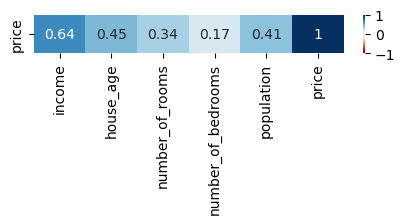

In [127]:
plt.figure(figsize = (5,0.5))
sns.heatmap(house.corr(numeric_only = True).iloc[-1:, :],
            vmin = -1, 
            vmax = 1, 
            cmap = "RdBu",
            annot = True);

**Observations:**
Price is correlated with 

1. Income - strongly
2. Age, population, no. of rooms - moderately
3. No of bedrooms - weakly


In [128]:
num_cols = house.select_dtypes(include = ["float"]).columns


In [129]:
num_cols

Index(['income', 'house_age', 'number_of_rooms', 'number_of_bedrooms',
       'population', 'price'],
      dtype='object')

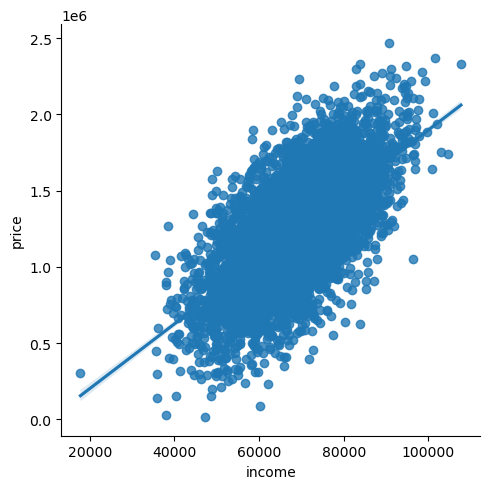

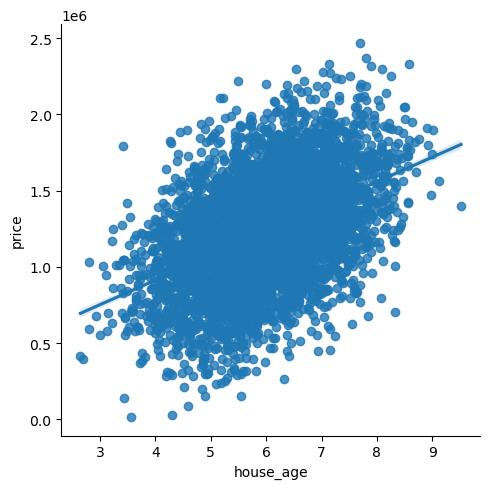

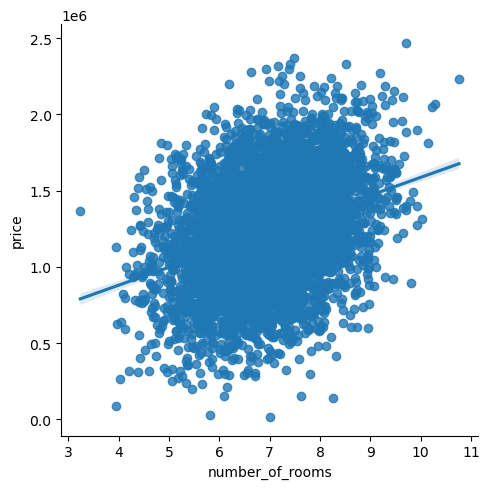

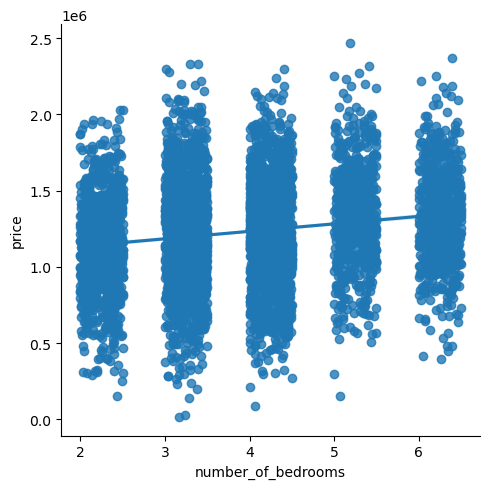

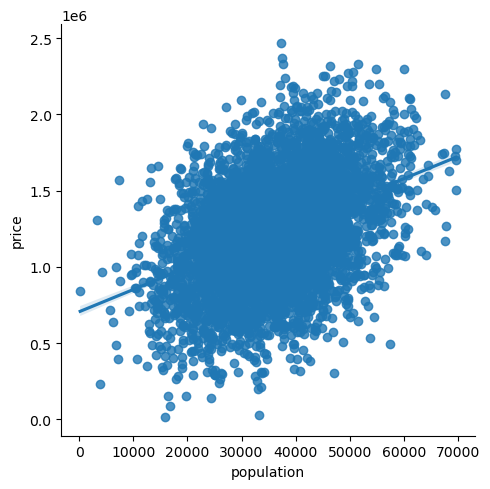

In [130]:


for i in num_cols:
    if i != "price":
        sns.lmplot(data = house, x = i, y = "price")




## 4. Model Tuning

In [131]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [132]:
X = house.drop(columns = ["price", "address"])
y = house["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

std_scaler = StandardScaler()

X_train_s = std_scaler.fit_transform(X_train)
X_test_s = std_scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train_s, y_train)

train_score = model.score(X_train_s, y_train)
test_r2 = r2_score(y_test, model.predict(X_test_s))

print(f"Train Score : {train_score} \n Train R2 : {test_r2}")



Train Score : 0.9179787435623722 
 Train R2 : 0.9179971706834331


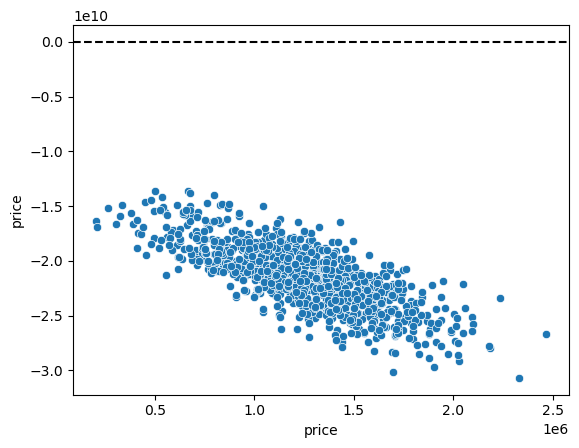

In [133]:
# Residual plot
y_pred = model.predict(X_test)
resid = y_test - y_pred

ax = sns.scatterplot(x = y_test, y = resid)
ax.axhline(y = 0, linestyle = "--", color = "black")



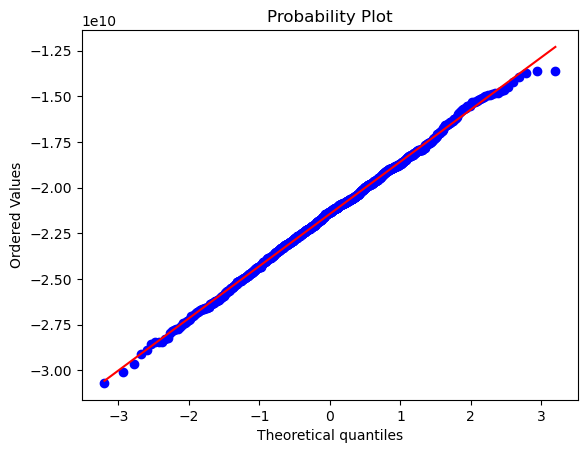

In [134]:
import scipy.stats as stats

stats.probplot(resid, dist = "norm", plot = plt);

In [135]:
mae = mean_absolute_error(y_test, y_pred)


In [136]:
mse = mean_squared_error(y_test, y_pred)


In [137]:
rsme = mean_squared_error(y_test, y_pred, squared = False)


In [138]:
print("R2:", test_r2)
print("MAE:", mae)
print("MSE:", mse)
print("RSME:", rsme)

R2: 0.9179971706834331
MAE: 21435913269.494694
MSE: 4.676264384118539e+20
RSME: 21624671983.91351


## 5. Pipeline

In [139]:
# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# onehotencoder # standardscaler # simpleimputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# model # train-test split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import joblib

In [140]:
df = pd.read_csv("data/USA_Housing.csv")
print(df.shape)
df.head()

(5000, 7)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [141]:

X = df.drop(columns = ["Price", "Address"])
y = df["Price"]

numerical_cols = X.select_dtypes(include = ["int64", "float64"]).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42) 

# Numerical
numerical_transformer = Pipeline([
                        ("impute", SimpleImputer(strategy = "mean")),
                        ("scaler", StandardScaler())
                        ])

# dataprep
data_prep = ColumnTransformer(transformers = [
                    ("numerical", numerical_transformer, numerical_cols)
                    ])
# model
LR = LinearRegression()

# final pipeline
model_pipeline = Pipeline([
                        ("impute_scaling", data_prep),
                        ("modelling_lr", LR)
                        ])


model_pipeline.fit(X_train, y_train)
model_pipeline.score(X_test, y_test)


0.9179971706834331

In [142]:
model_pipeline

Pipeline(steps=[('impute_scaling',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population'],
      dtype='object'))])),
                ('modelling_lr', LinearRegression())])

In [143]:
joblib.dump(model_pipeline, "models/house_price_lr.pkl")

['models/house_price_lr.pkl']

In [144]:
## Prediction
to_predict_df = pd.DataFrame({
                        "Avg. Area Income" : [68000, 73000, 71112],
                        "Avg. Area House Age" : [5.9, 6.4, 6.0],
                        "Avg. Area Number of Rooms" : [6.9, 7.7, 7.1],
                        "Avg. Area Number of Bedrooms" : [3.9, 4.8, 4.1],
                        "Area Population" : [37000, 43000, 35000] 
                        })

# price - 1,232,073, 1,413,341, 1,285,099

In [145]:
to_predict_df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,68000,5.9,6.9,3.9,37000
1,73000,6.4,7.7,4.8,43000
2,71112,6.0,7.1,4.1,35000


In [146]:
model = joblib.load("models/house_price_lr.pkl")

In [147]:
np.round(model.predict(to_predict_df), 2)

array([1208734.08, 1588845.78, 1286454.64])

In [148]:
## - End of Analysis -- ##